In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def get_palette(list_of_colors: list):
    palette= {'Black/Dark gray': "#0a0a0a",  'Blue':"#0a62fa", 'Green':"#1aaf00",  'Light gray/Silver':"#c8c8c8", 'Orange':"#f77e0d",'Red':"#fa0a0a",'White':"#f5f5f5", 'Yellow':"#ffe600"}
    return [palette[i] for i in list_of_colors]

lighting_palette = palette=["#FFE368", "#8B8462", "#282828"]

In [3]:
internal = pd.read_csv('../annotations/internal.csv')
external = pd.read_csv("../annotations/external.csv")

# De to linjene under er basert på: https://stackoverflow.com/questions/71523769/merge-two-columns-into-one-with-nan-values
internal["year"] = internal[["year_3", "year_s", "year_x", "year_y"]].bfill(axis="columns").iloc[:,0]
external["year"] = external[["year_3", "year_s", "year_x", "year_y"]].bfill(axis="columns").iloc[:,0]

# De to linjene under er basert på: https://stackoverflow.com/questions/40389018/dropping-multiple-columns-from-a-dataframe
internal.drop(["year_3", "year_s", "year_x", "year_y"], axis=1, inplace=True)
external.drop(["year_3", "year_s", "year_x", "year_y"], axis=1, inplace=True)

internal["source"] = 'intern'
external["source"] = 'ekstern'

In [4]:
annotations = {
    "Intern": {
        "cars": internal,
        "filtered": {
            "Model S": internal[internal['model'] == 'S'],
            "Model X": internal[internal['model'] == 'X'],
            "Model 3": internal[internal['model'] == '3'],
            "Model Y": internal[internal['model'] == 'Y'],
        }
    },
    "Ekstern": {
        "cars": external,
        "filtered": {
            "Model S": external[external['model'] == 'S'],
            "Model X": external[external['model'] == 'X'],
            "Model 3": external[external['model'] == '3'],
            "Model Y": external[external['model'] == 'Y'],
        }
    },
    "Alle": {
        "cars": pd.concat([internal, external], ignore_index=True),
        "filtered": {
            "Model S": pd.concat([internal[internal['model'] == 'S'], external[external['model'] == 'S']], ignore_index=True),
            "Model X": pd.concat([internal[internal['model'] == 'X'], external[external['model'] == 'X']], ignore_index=True),
            "Model 3": pd.concat([internal[internal['model'] == '3'], external[external['model'] == '3']], ignore_index=True),
            "Model Y": pd.concat([internal[internal['model'] == 'Y'], external[external['model'] == 'Y']], ignore_index=True),
        }
    }
}

other = 'Other car'

sns.set_theme(style="darkgrid", font_scale=0.9)

/tmp/ipykernel_20223/4127453105.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=data, palette=["#fa0a0a", "#6f6f6f"])


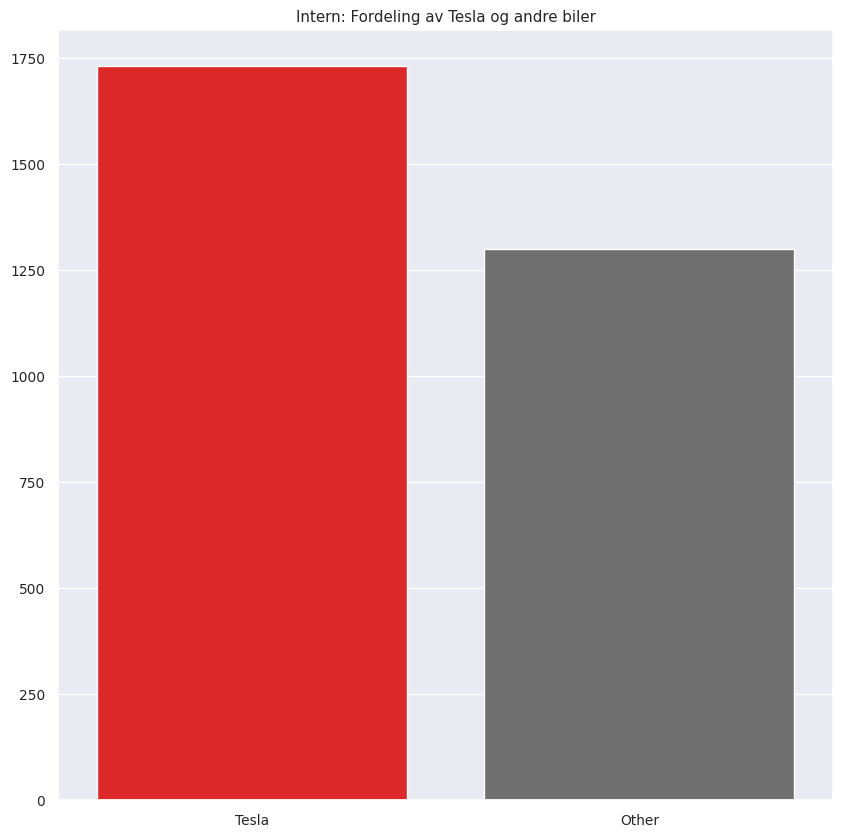

/tmp/ipykernel_20223/4127453105.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=data, palette=["#fa0a0a", "#6f6f6f"])


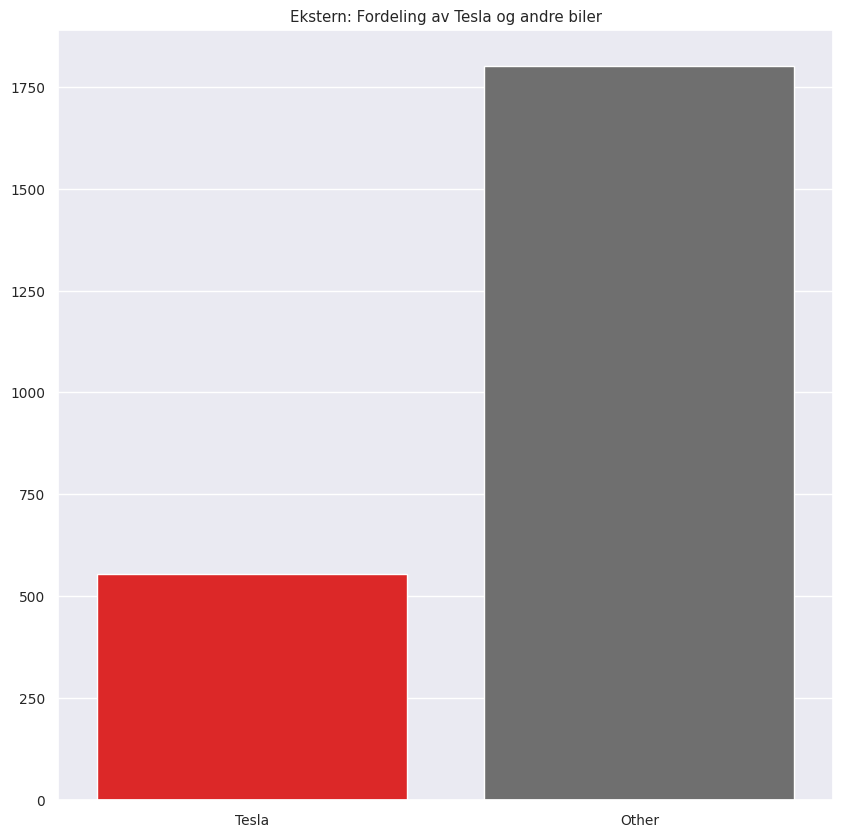

/tmp/ipykernel_20223/4127453105.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=data, palette=["#fa0a0a", "#6f6f6f"])


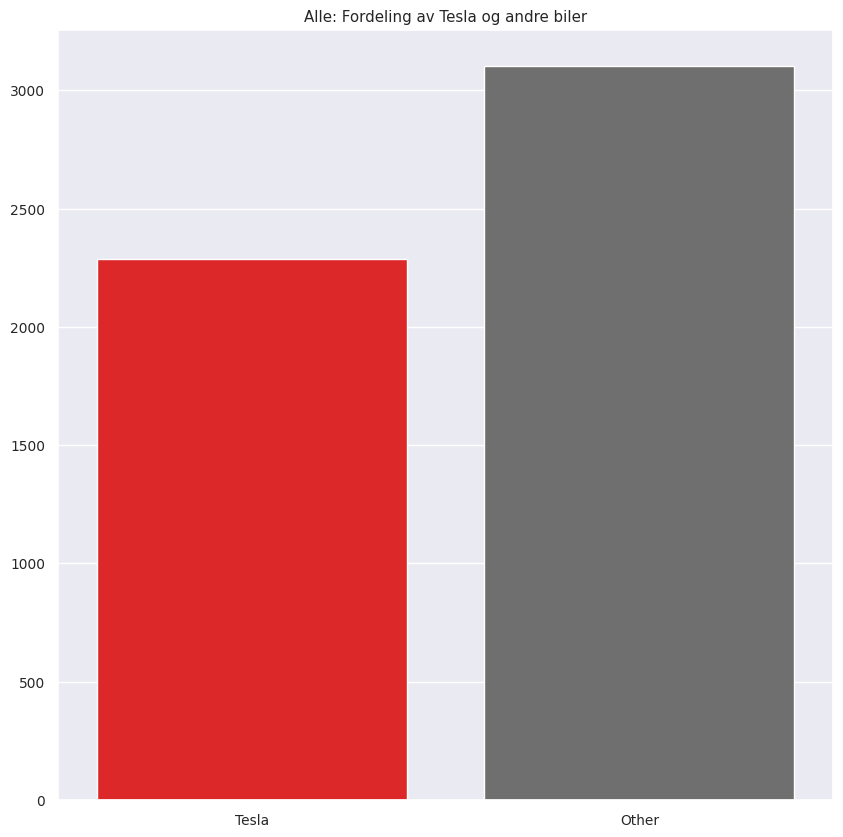

In [5]:
from matplotlib import pyplot

for annotation_name, annotation in annotations.items():
    df = annotation["cars"]
    pyplot.figure(figsize=(10,10))
    data={'Tesla': len(df[df['model'] != other]), 'Other': len(df[df['model'] == other])}
    plot = sns.barplot(data=data, palette=["#fa0a0a", "#6f6f6f"])
    plot.set_title(f'{annotation_name}: Fordeling av Tesla og andre biler')
    plt.show()

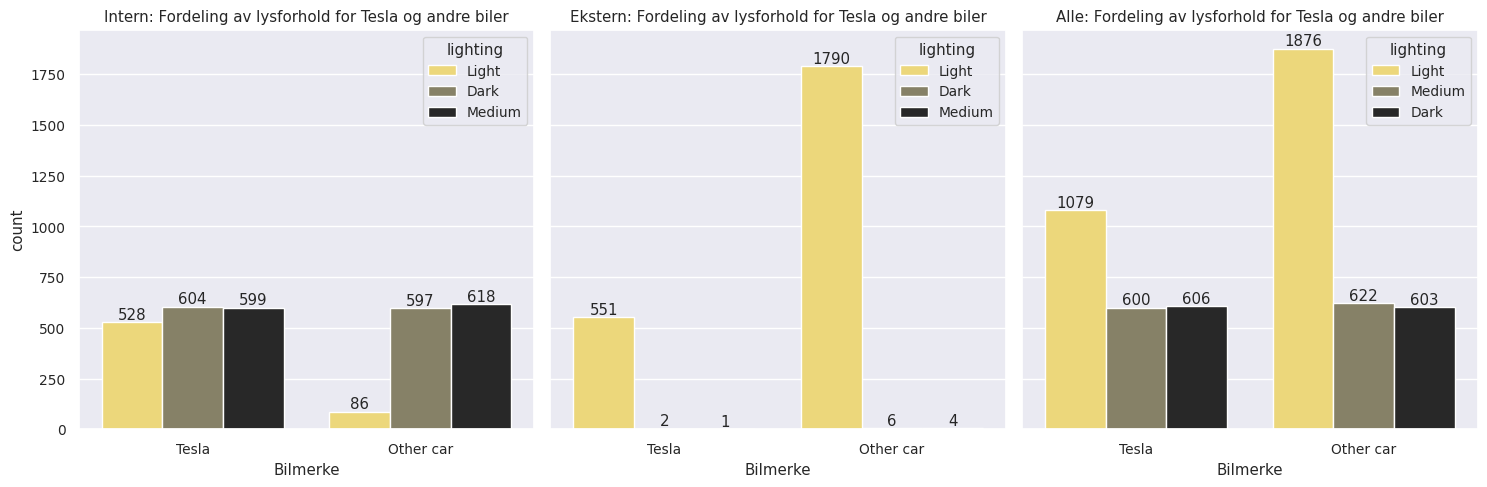

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Finn ut hvor mange annotations du har for å lage riktig antall subplots
num_plots = len(annotations)

# Opprett en figur med flere axis-objekter (f.eks. 1 rad, N kolonner)
fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 5), sharey=True)

# Hvis du bare har 1 plot, gjør vi axes om til en liste så løkken ikke krasjer
if num_plots == 1:
    axes = [axes]

for ax, (annotation_name, annotation) in zip(axes, annotations.items()):
    df = annotation["cars"].copy()
    
    # Datapreparering
    # Linjen under er basert på https://stackoverflow.com/questions/31511997/pandas-dataframe-replace-all-values-in-a-column-based-on-condition
    df.loc[df["model"] != "Other car", "model"] = "Tesla"
    df = df.sort_values(by="model", ascending=False)
    
    # Tegn på den spesifikke aksen (ax)
    # Koden under er basert på https://seaborn.pydata.org/generated/seaborn.countplot.html
    sns.countplot(
        data=df, 
        x="model", 
        hue="lighting", 
        palette=lighting_palette, 
        ax=ax
    )
    
    # Annoteringer
    # Løkken under er basert på https://stackoverflow.com/questions/55104819/display-count-on-top-of-seaborn-barplot
    for container in ax.containers:
        ax.bar_label(container)
        
    ax.set_title(f'{annotation_name}: Fordeling av lysforhold for Tesla og andre biler')
    ax.set_xlabel("Bilmerke")

# Justerer avstand mellom plottene så de ikke overlapper
plt.tight_layout()
plt.show()

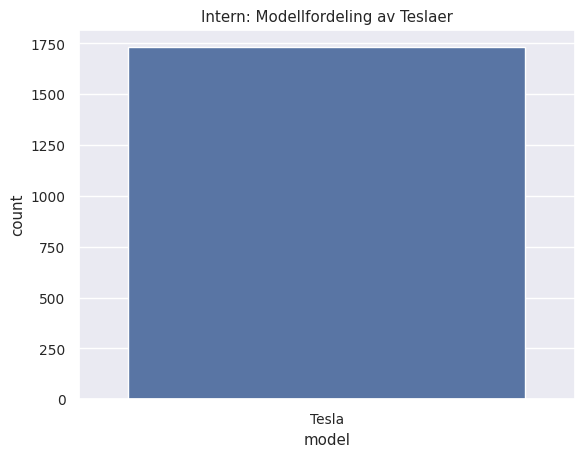

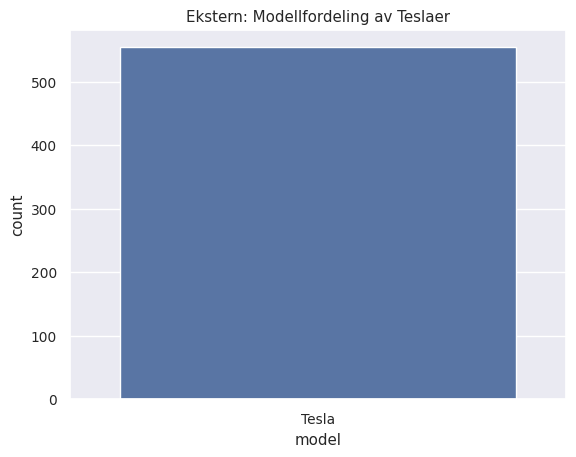

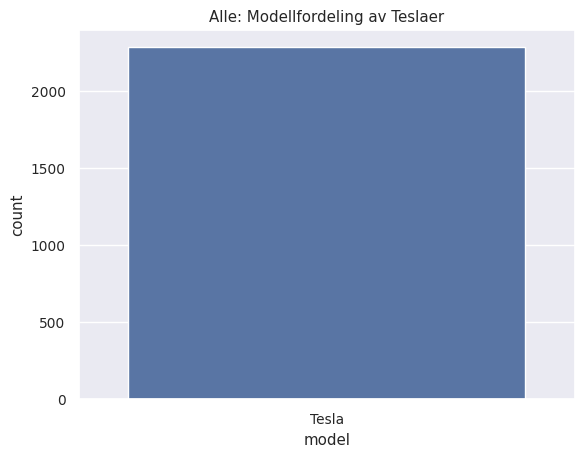

In [7]:
for annotation_name, annotation in annotations.items():
    df = annotation["cars"]
    data = df[df['model'] != other]
    plot = sns.countplot(data=data, x='model', hue='model')
    plot.set_title(f'{annotation_name}: Modellfordeling av Teslaer')
    plt.show()

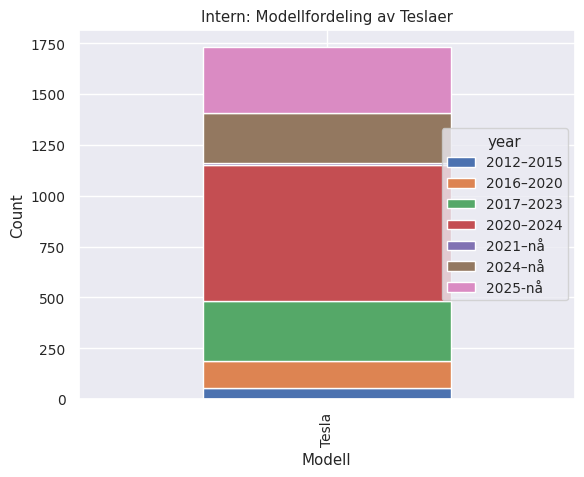

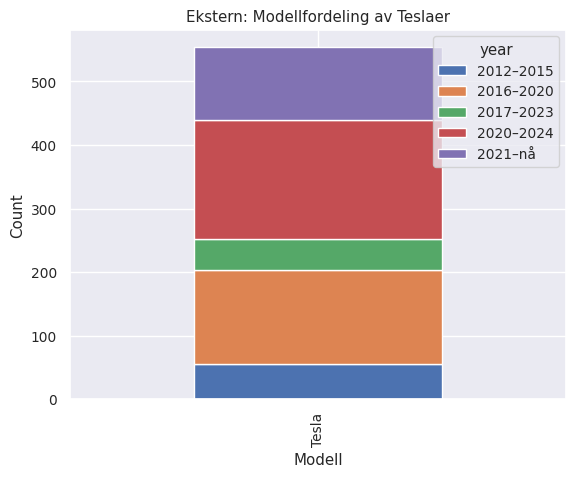

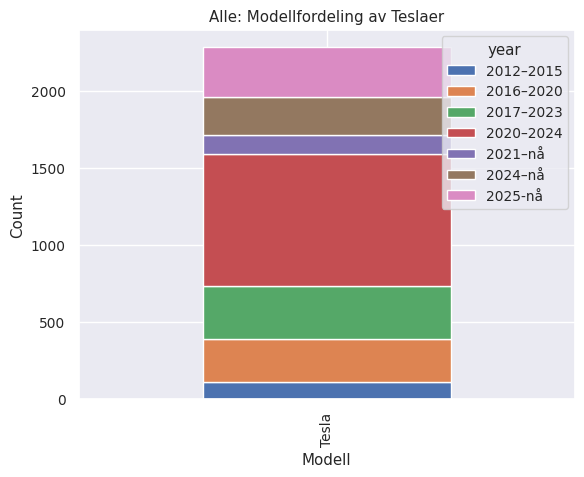

In [8]:
for annotation_name, annotation in annotations.items():
    df = annotation["cars"]
    data = df[df['model'] != 'other']
    crosstab = pd.crosstab(data['model'], data['year'])
    crosstab.plot(kind='bar', stacked=True)

    plt.title(f'{annotation_name}: Modellfordeling av Teslaer')
    plt.xlabel('Modell')
    plt.ylabel('Count')
    plt.show()

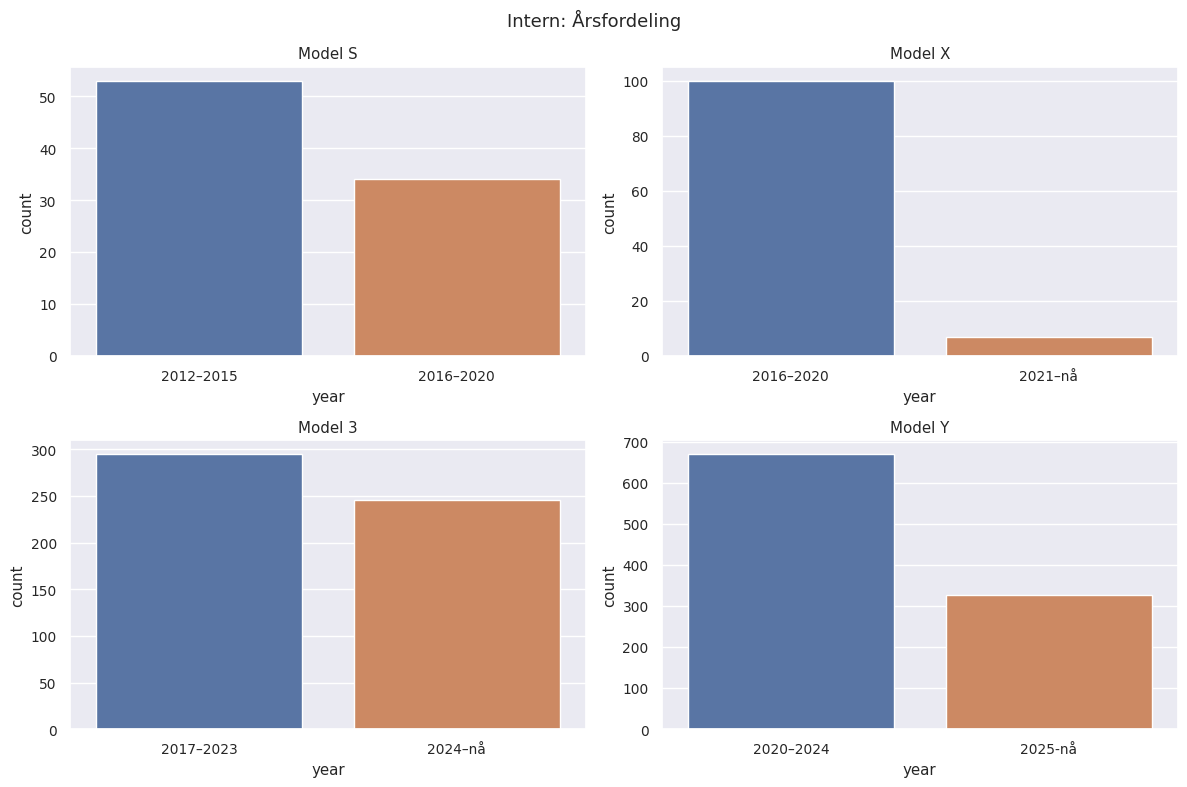

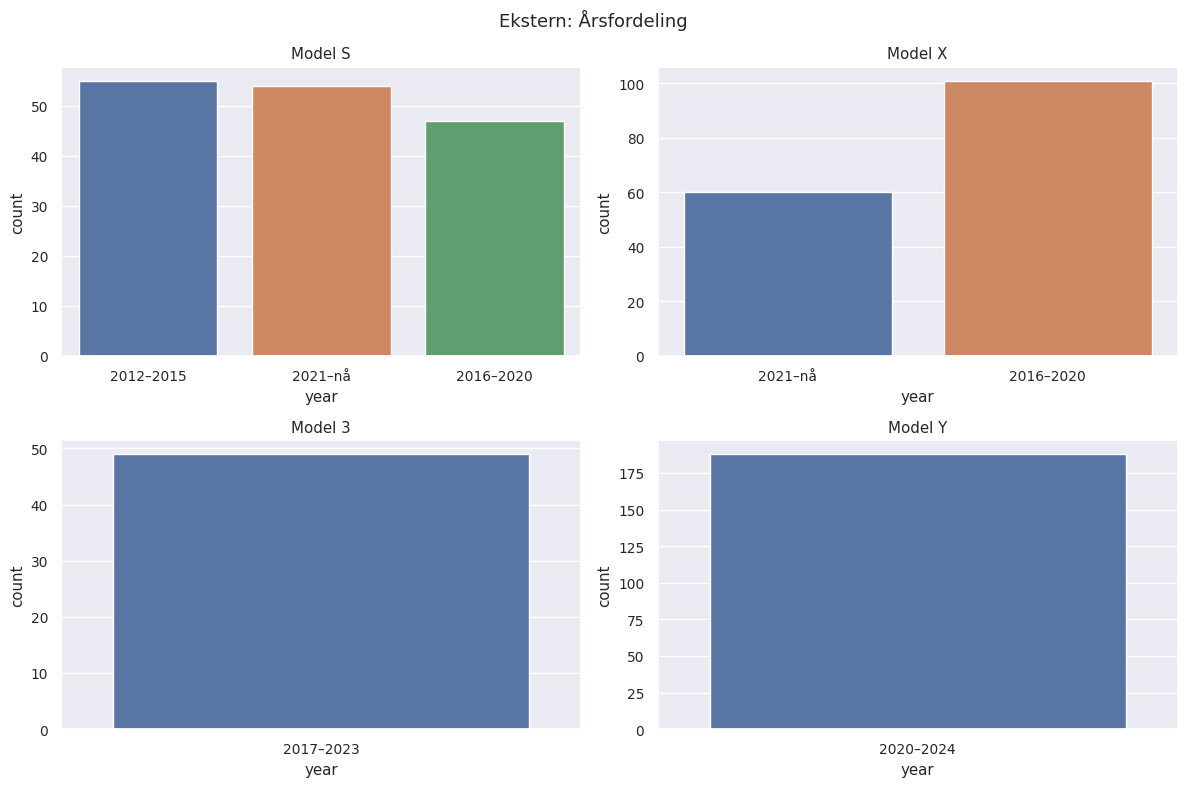

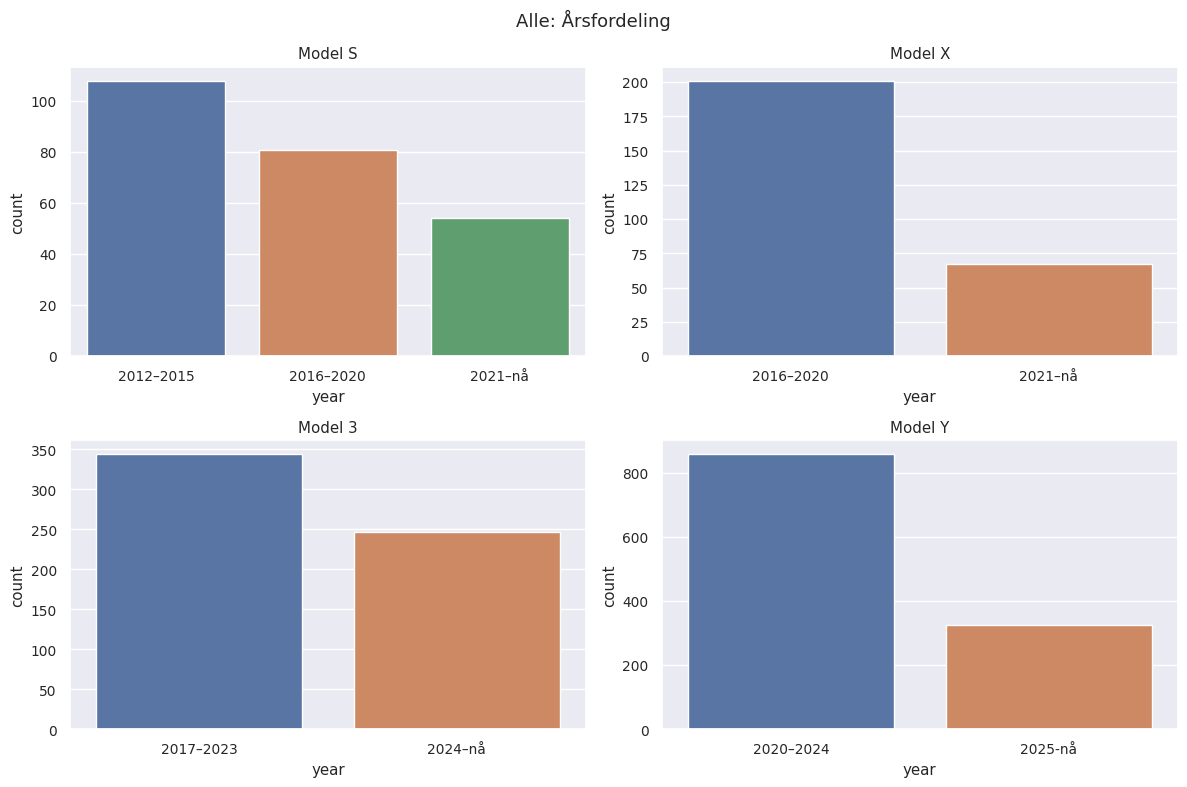

In [9]:
for annotation_name, annotation in annotations.items():
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{annotation_name}: Årsfordeling')
    for i in range(0,2):
        for j in range(0,2):
            sns.countplot(x='year', data=list(annotation["filtered"].values())[(2*i)+j], ax=axes[i,j], hue='year')
            axes[i,j].title.set_text(list(annotation["filtered"].keys())[(2*i)+j])

    plt.tight_layout()
    plt.show()

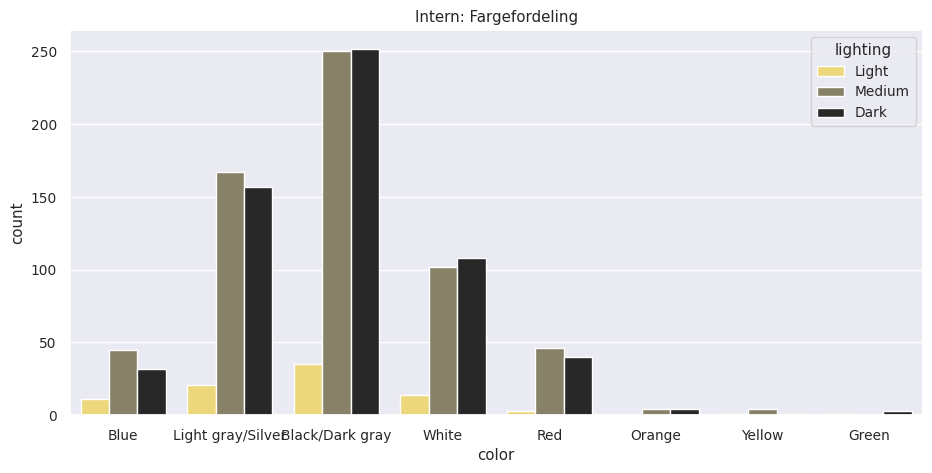

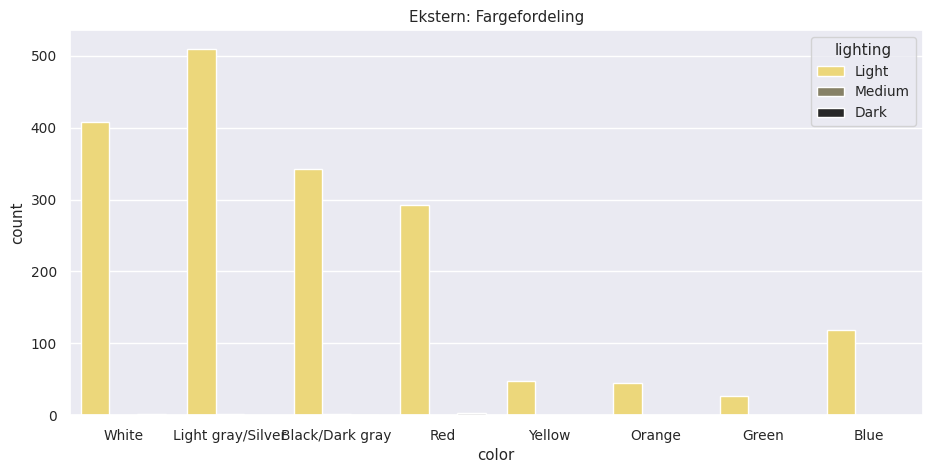

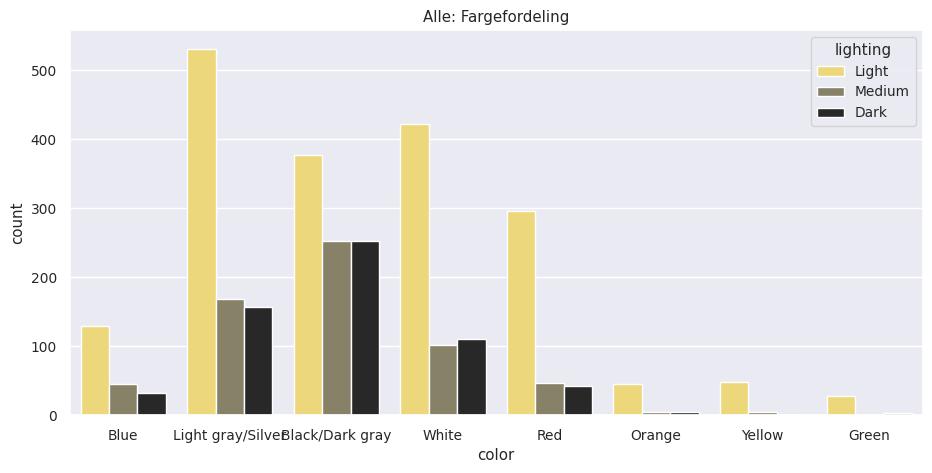

In [10]:
for annotation_name, annotation in annotations.items():
    f = plt.figure()
    f.set_figwidth(11)
    f.set_figheight(5)
    df = annotation["cars"]
    data = df[df['model'] == other]
    fig = sns.countplot(data=data, x='color', hue='lighting', palette=lighting_palette)
    fig.set_title(f'{annotation_name}: Fargefordeling')
    plt.show()


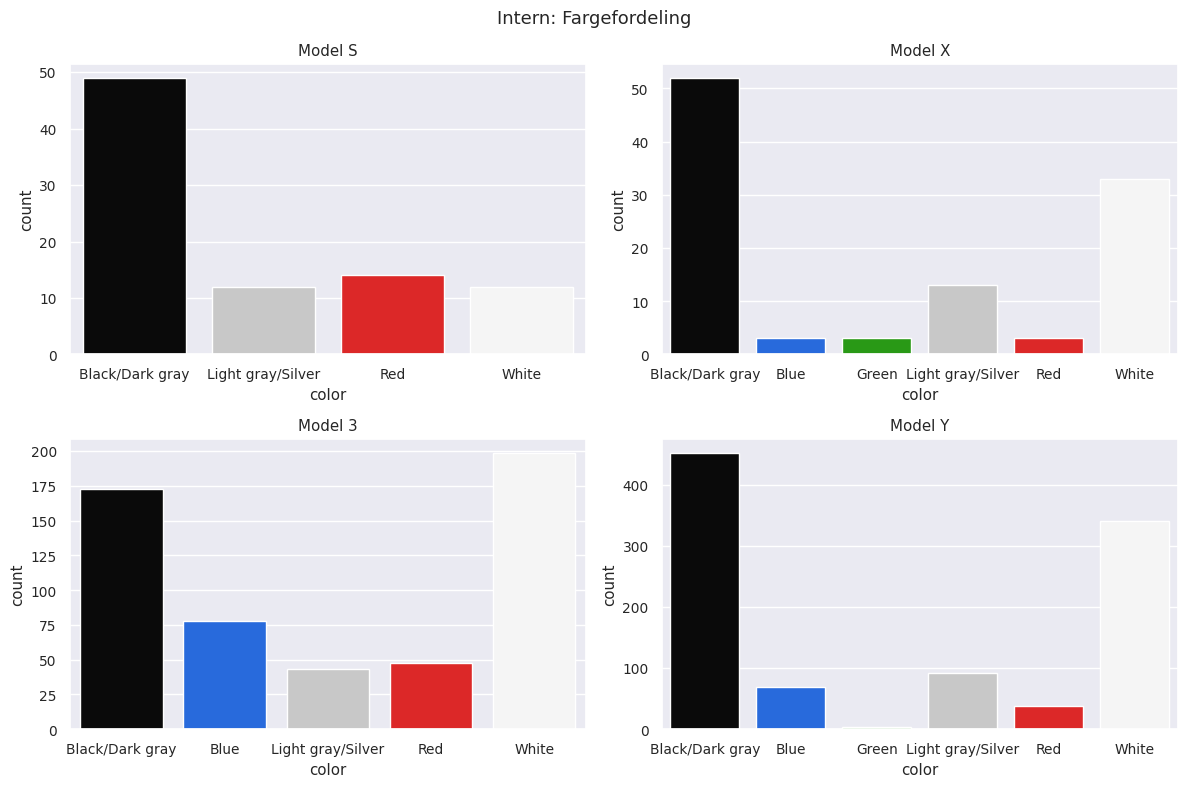

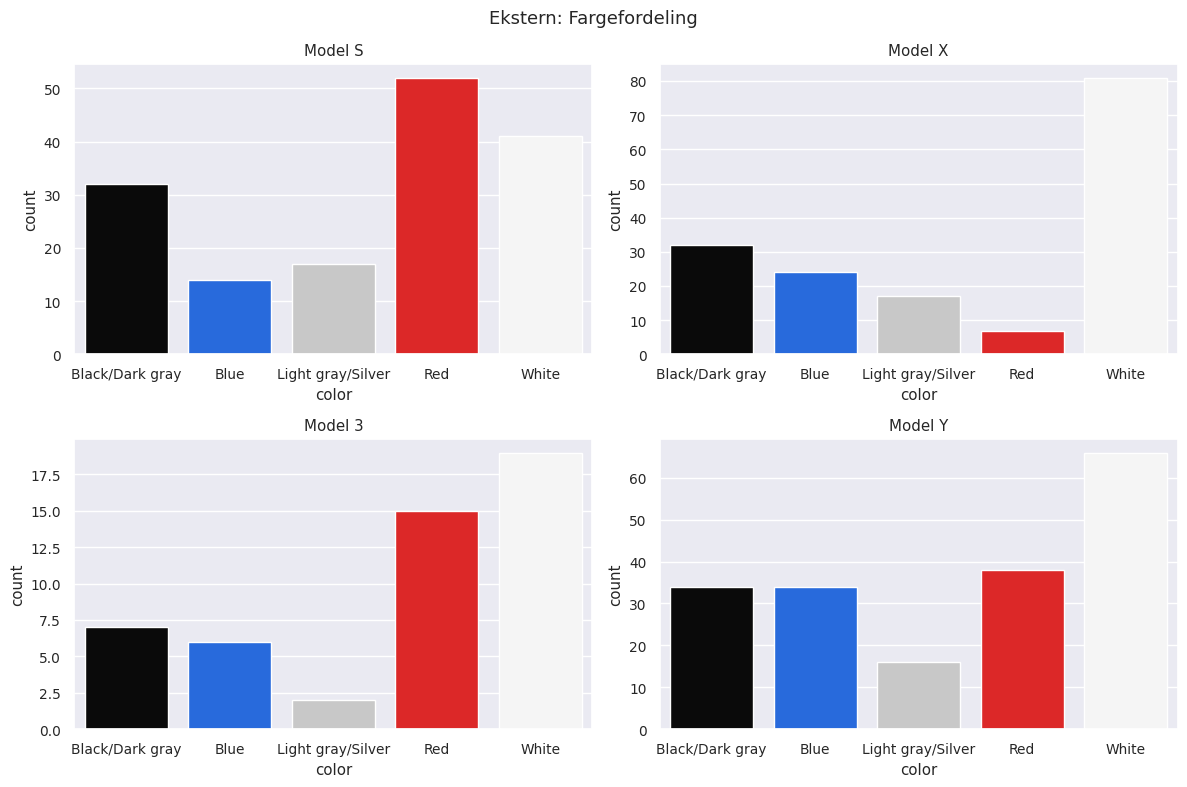

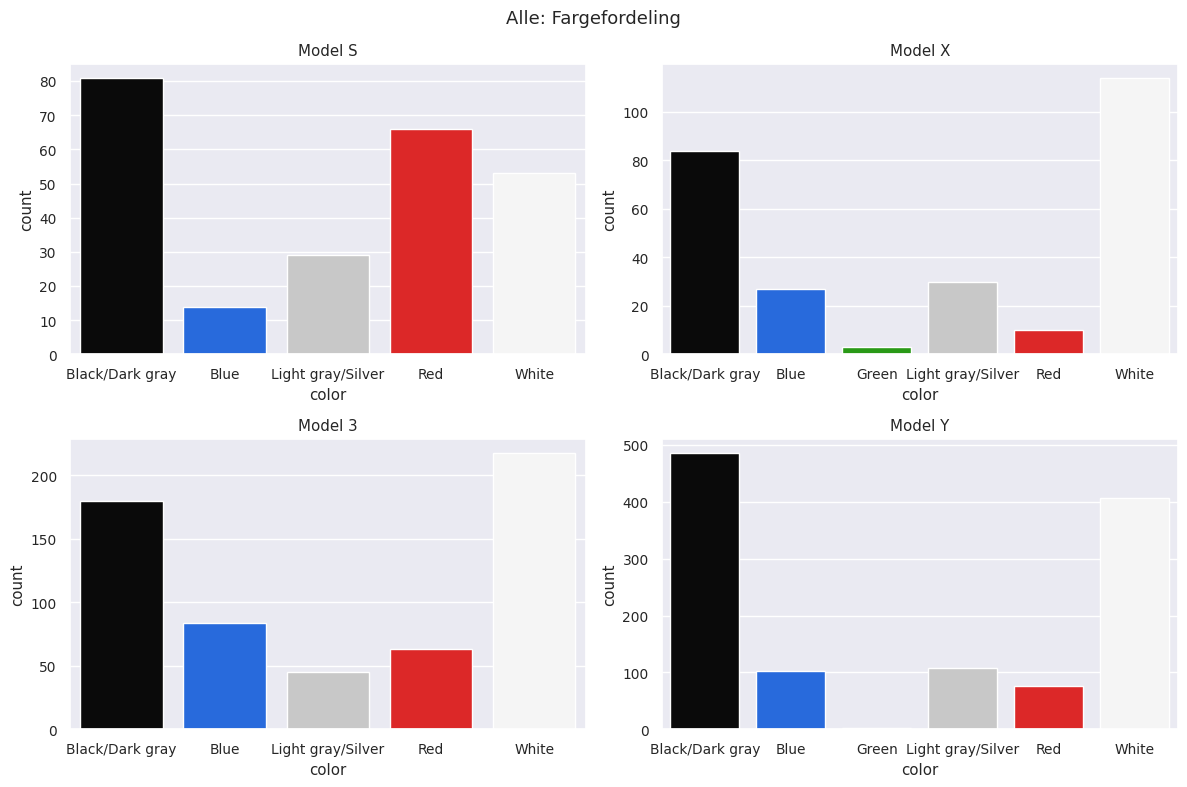

In [11]:
for annotation_name, annotation in annotations.items():
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{annotation_name}: Fargefordeling')
    for i in range(0,2):
        for j in range(0,2):
            data = list(annotation["filtered"].values())[(2*i)+j].sort_values(by="color")
            sns.countplot(x='color', data=data, ax=axes[i,j], hue="color", palette=get_palette(data["color"].unique()))
            axes[i,j].title.set_text(list(annotation["filtered"].keys())[(2*i)+j])

    plt.tight_layout()
    plt.show()

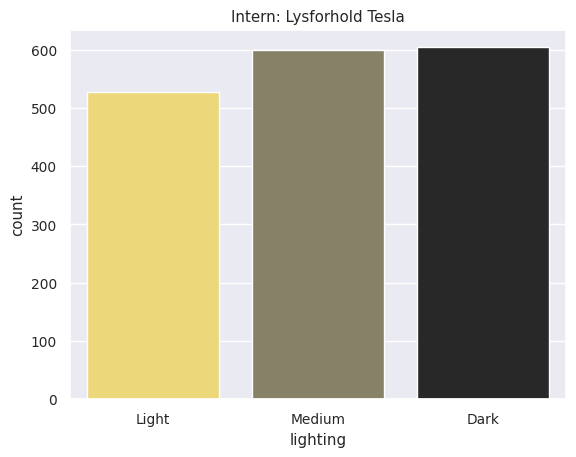

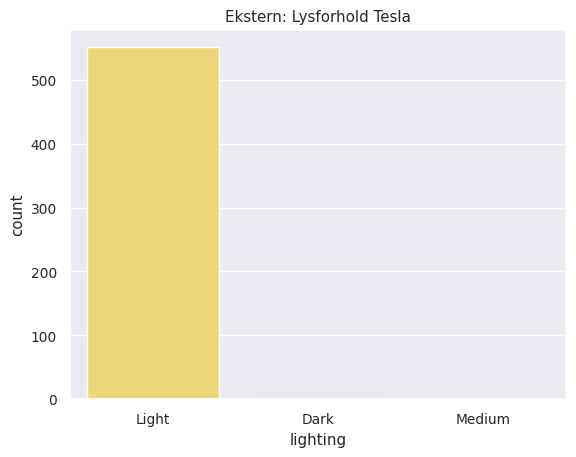

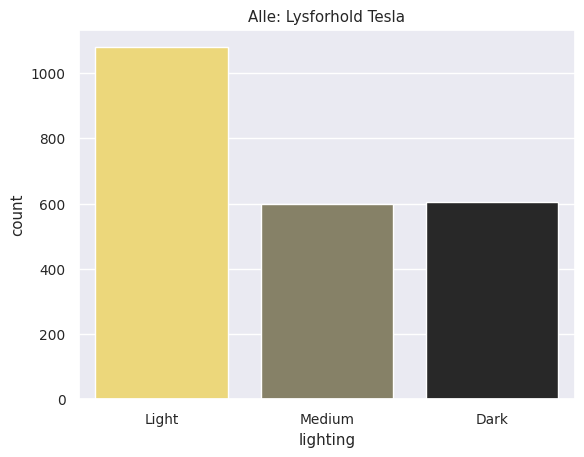

In [12]:
for annotation_name, annotation in annotations.items():
    df = annotation["cars"]
    plot = sns.countplot(data=df[df['model'] != other], x='lighting', hue='lighting', palette=lighting_palette)
    plot.set_title(f'{annotation_name}: Lysforhold Tesla')
    plt.show()

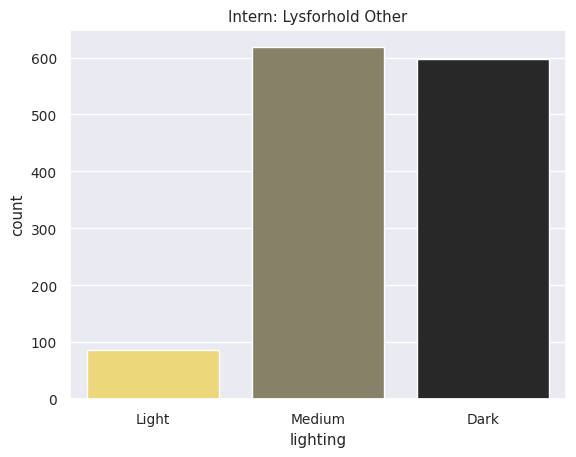

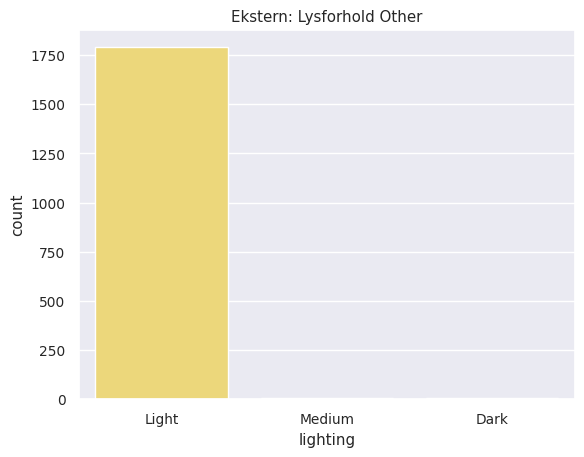

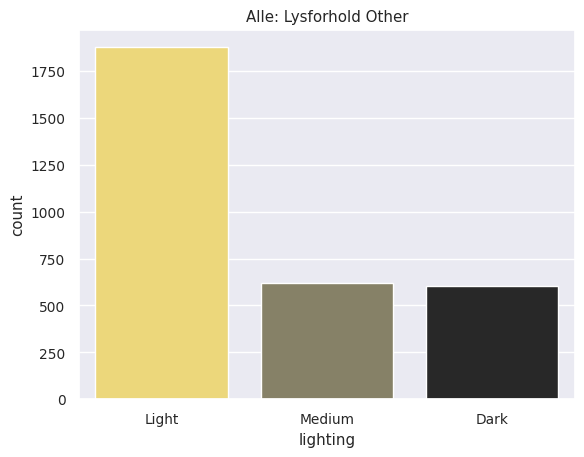

In [13]:
for annotation_name, annotation in annotations.items():
    df = annotation["cars"]
    plot = sns.countplot(data=df[df['model'] == other], x='lighting', hue='lighting', palette=lighting_palette)
    plot.set_title(f'{annotation_name}: Lysforhold Other')
    plt.show()

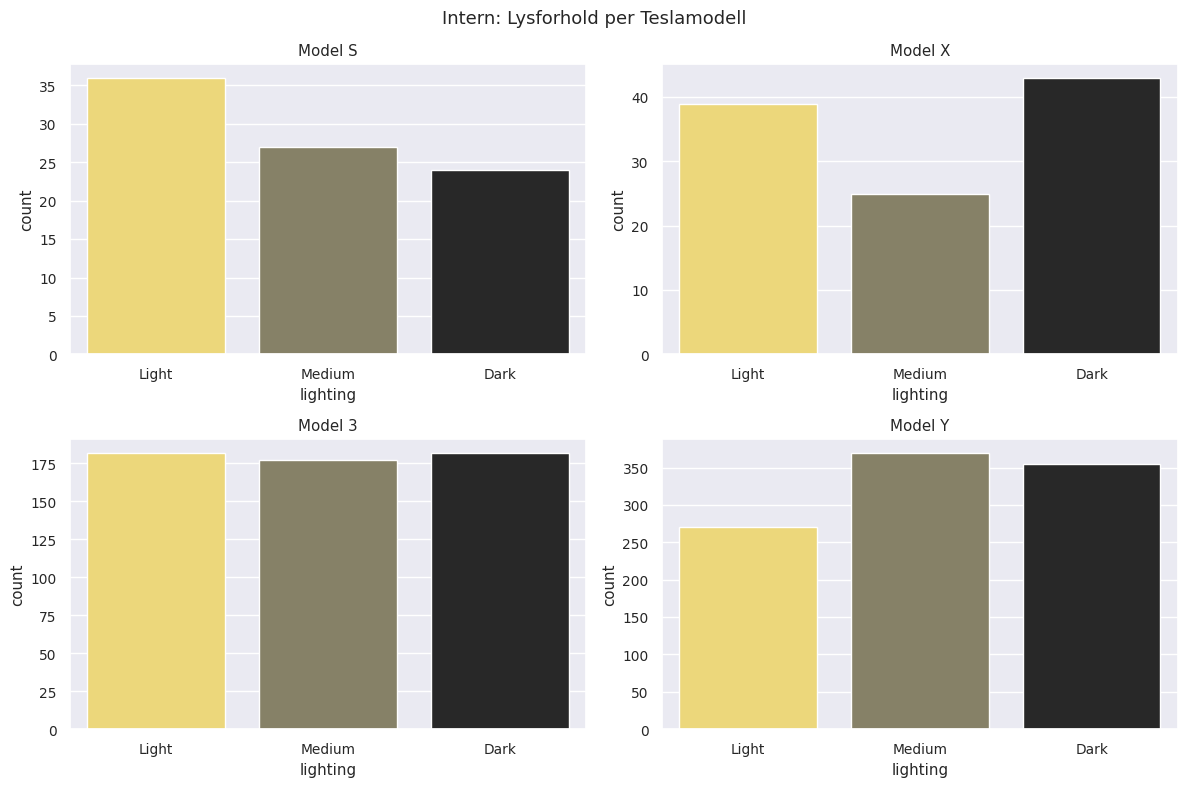

/tmp/ipykernel_20223/565526195.py:5: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.countplot(x='lighting', data=list(annotation["filtered"].values())[0], ax=axes[0,0], hue='lighting', palette=lighting_palette)
/tmp/ipykernel_20223/565526195.py:6: UserWarning: The palette list has more values (3) than needed (1), which may not be intended.
  sns.countplot(x='lighting', data=list(annotation["filtered"].values())[1], ax=axes[0,1], hue='lighting', palette=lighting_palette)
/tmp/ipykernel_20223/565526195.py:7: UserWarning: The palette list has more values (3) than needed (1), which may not be intended.
  sns.countplot(x='lighting', data=list(annotation["filtered"].values())[2], ax=axes[1,0], hue='lighting', palette=lighting_palette)
/tmp/ipykernel_20223/565526195.py:8: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.countplot(x='lighting', data=list(annotation["filtered"].values())[3], 

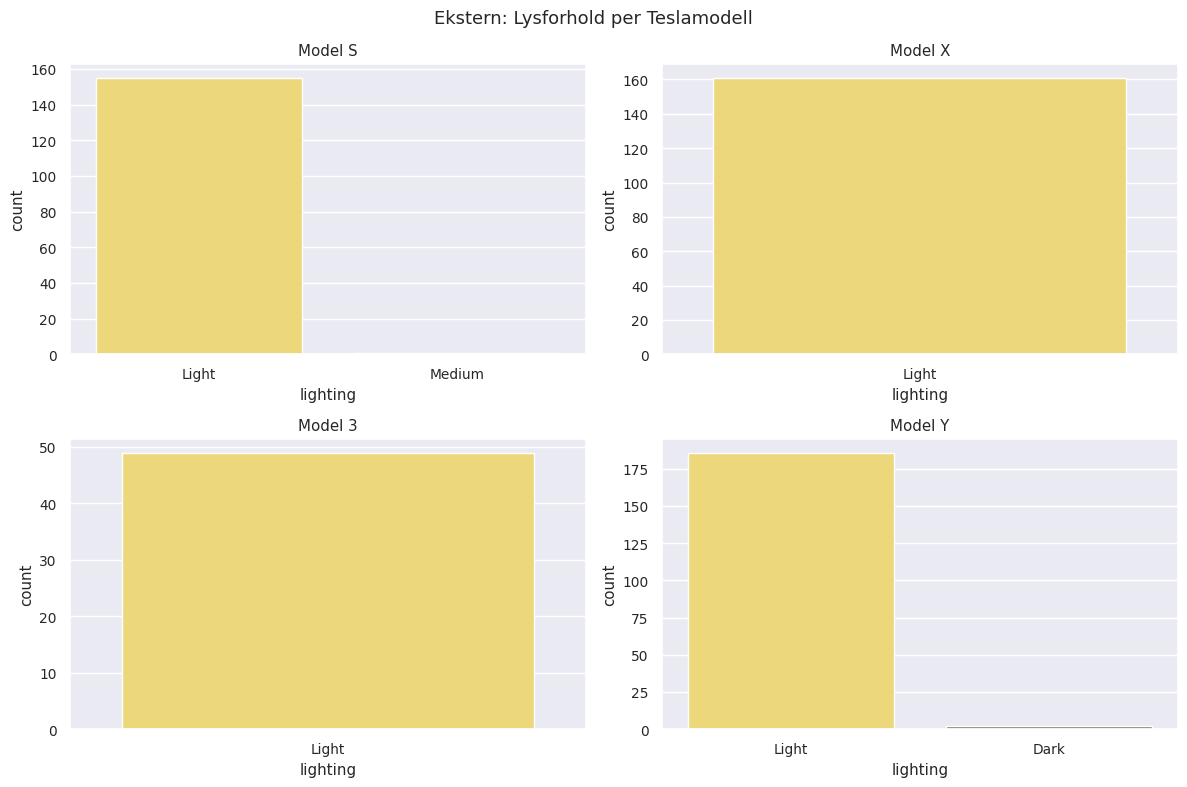

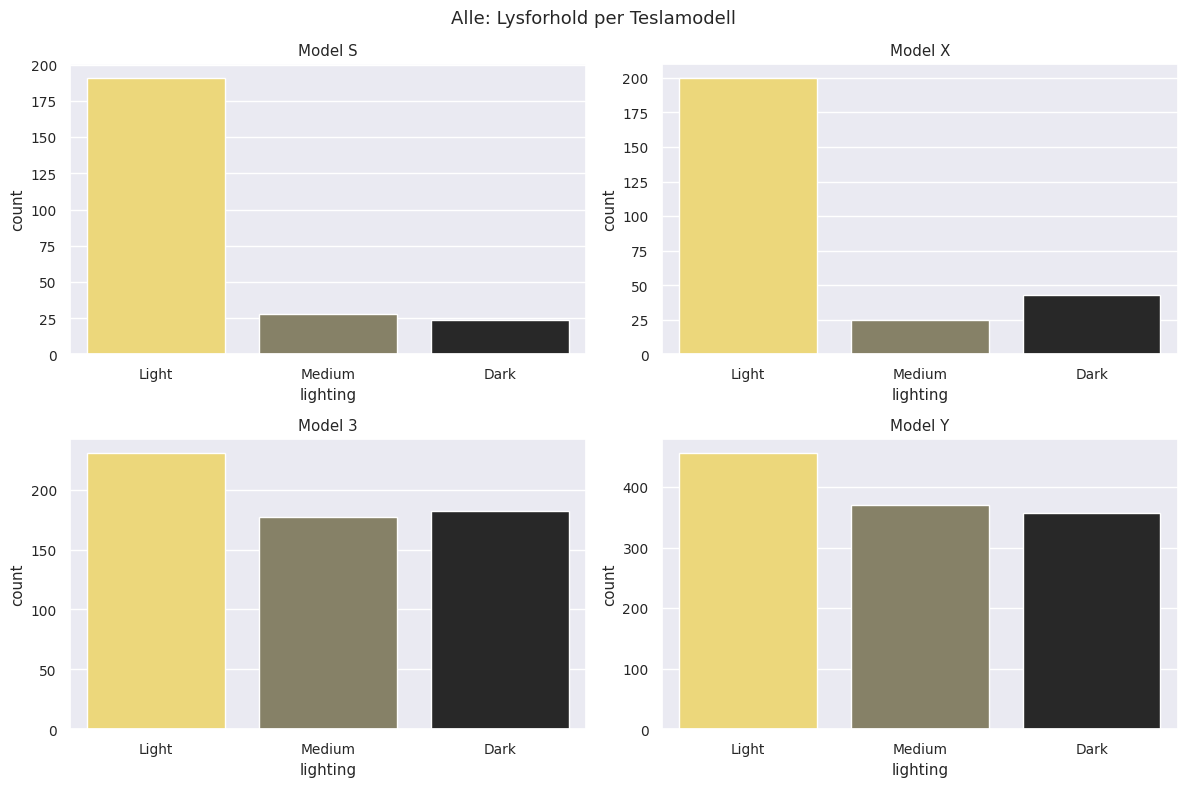

In [14]:
for annotation_name, annotation in annotations.items():
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{annotation_name}: Lysforhold per Teslamodell')

    sns.countplot(x='lighting', data=list(annotation["filtered"].values())[0], ax=axes[0,0], hue='lighting', palette=lighting_palette)
    sns.countplot(x='lighting', data=list(annotation["filtered"].values())[1], ax=axes[0,1], hue='lighting', palette=lighting_palette)
    sns.countplot(x='lighting', data=list(annotation["filtered"].values())[2], ax=axes[1,0], hue='lighting', palette=lighting_palette)
    sns.countplot(x='lighting', data=list(annotation["filtered"].values())[3], ax=axes[1,1], hue='lighting', palette=lighting_palette)
    axes[0,0].title.set_text(list(annotation["filtered"].keys())[0])
    axes[0,1].title.set_text(list(annotation["filtered"].keys())[1])
    axes[1,0].title.set_text(list(annotation["filtered"].keys())[2])
    axes[1,1].title.set_text(list(annotation["filtered"].keys())[3])

    plt.tight_layout()
    plt.show()

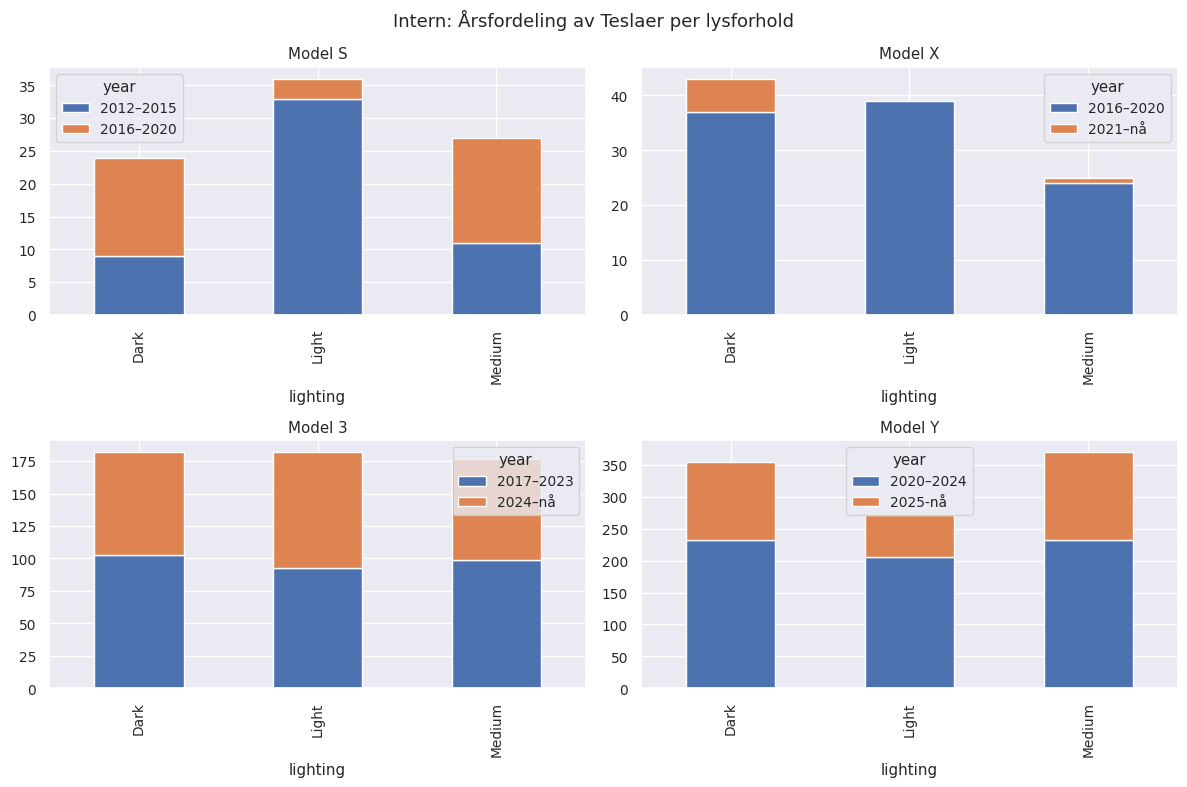

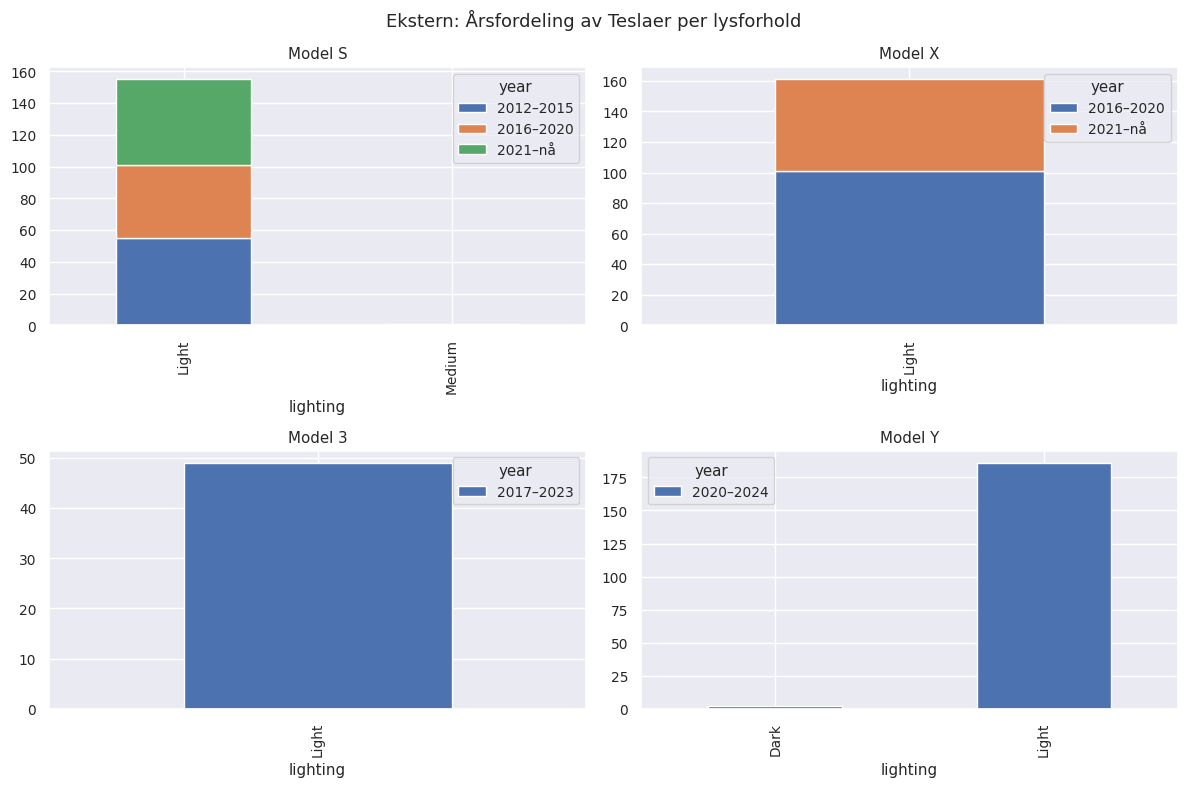

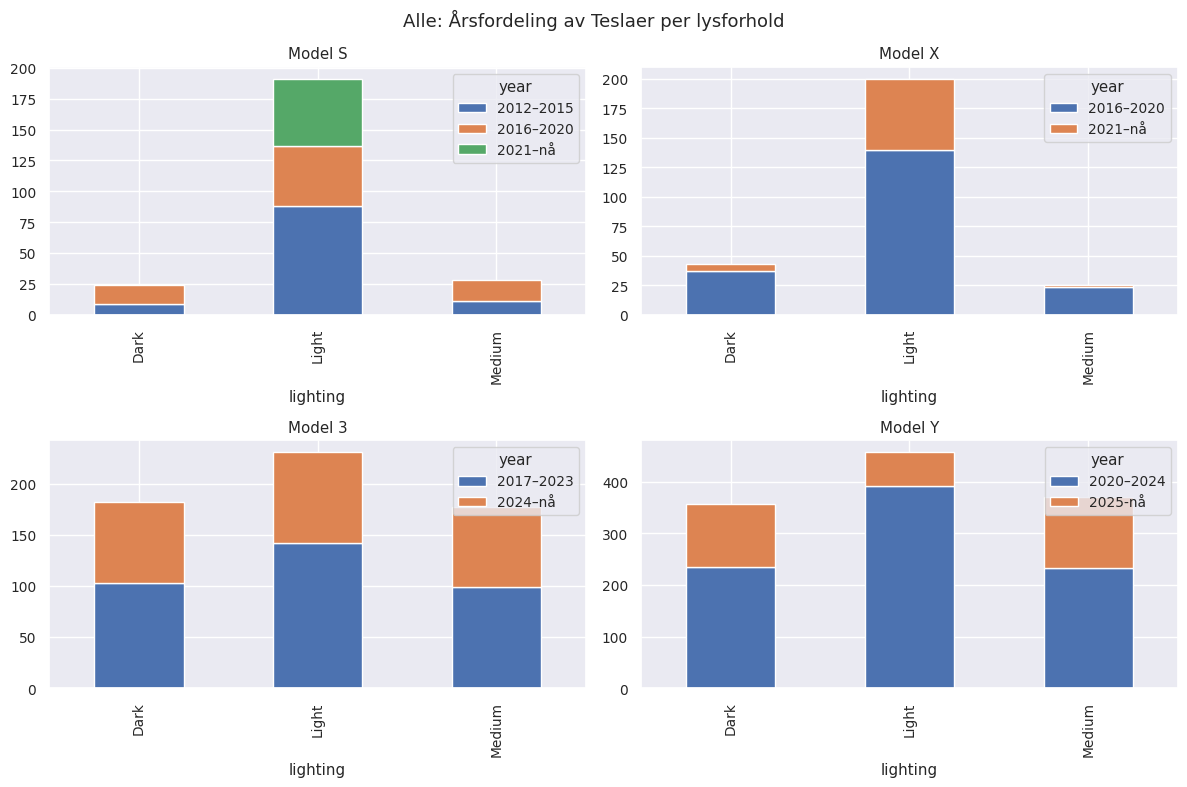

In [15]:
for annotation_name, annotation in annotations.items():
    df = annotation["filtered"]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{annotation_name}: Årsfordeling av Teslaer per lysforhold')

    crosstab_1 = pd.crosstab(list(df.values())[0]['lighting'], list(df.values())[0]['year'])
    crosstab_2 = pd.crosstab(list(df.values())[1]['lighting'], list(df.values())[1]['year'])
    crosstab_3 = pd.crosstab(list(df.values())[2]['lighting'], list(df.values())[2]['year'])
    crosstab_4 = pd.crosstab(list(df.values())[3]['lighting'], list(df.values())[3]['year'])

    axes[0,0].title.set_text(list(df.keys())[0])
    axes[0,1].title.set_text(list(df.keys())[1])
    axes[1,0].title.set_text(list(df.keys())[2])
    axes[1,1].title.set_text(list(df.keys())[3])
    
    crosstab_1.plot(kind='bar', stacked=True, ax=axes[0,0])
    crosstab_2.plot(kind='bar', stacked=True, ax=axes[0,1])
    crosstab_3.plot(kind='bar', stacked=True, ax=axes[1,0])
    crosstab_4.plot(kind='bar', stacked=True, ax=axes[1,1])

    plt.tight_layout()
    plt.show()

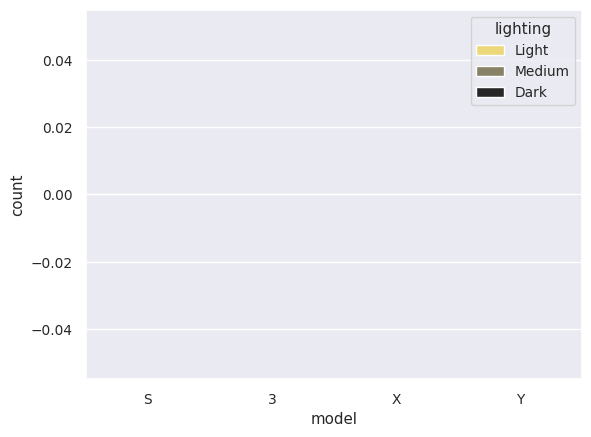

In [16]:

internal_data = internal
internal_data["source"] = 'intern'
external_data = external
external_data["source"] = 'ekstern'

combined_data = pd.concat([internal_data, external_data], ignore_index=True)


model_order = ['S', '3', 'X', 'Y']
combined_data['model'] = pd.Categorical(combined_data['model'], categories=model_order, ordered=True)

combined_data = combined_data.sort_values(by="model")

sns.countplot(x='model', data=combined_data, hue='lighting', palette=lighting_palette)
plt.show()

/tmp/ipykernel_20223/3448522165.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


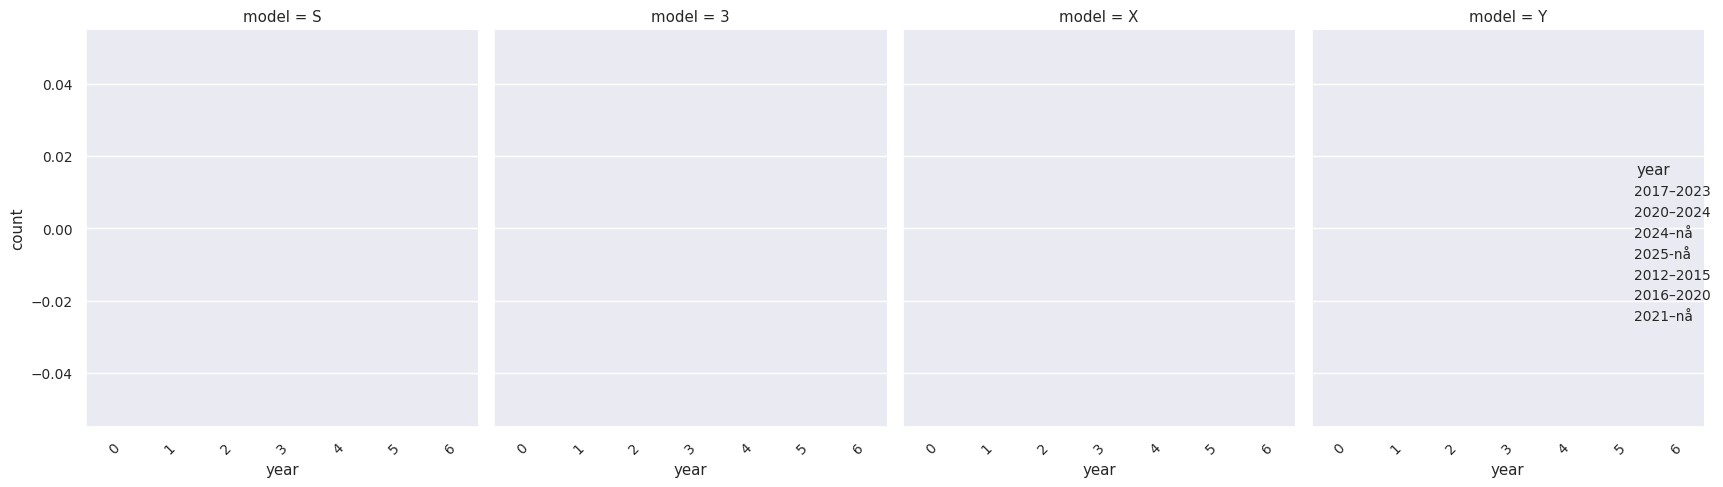

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ['S', '3', 'X', 'Y']
combined_data['model'] = pd.Categorical(combined_data['model'], categories=model_order, ordered=True)

g = sns.catplot(
    data=combined_data,
    x='year', 
    col='model',     
    kind='count',
    sharex=False,    
    palette='viridis',
    height=5, 
    aspect=0.8,
)


for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, padding=3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

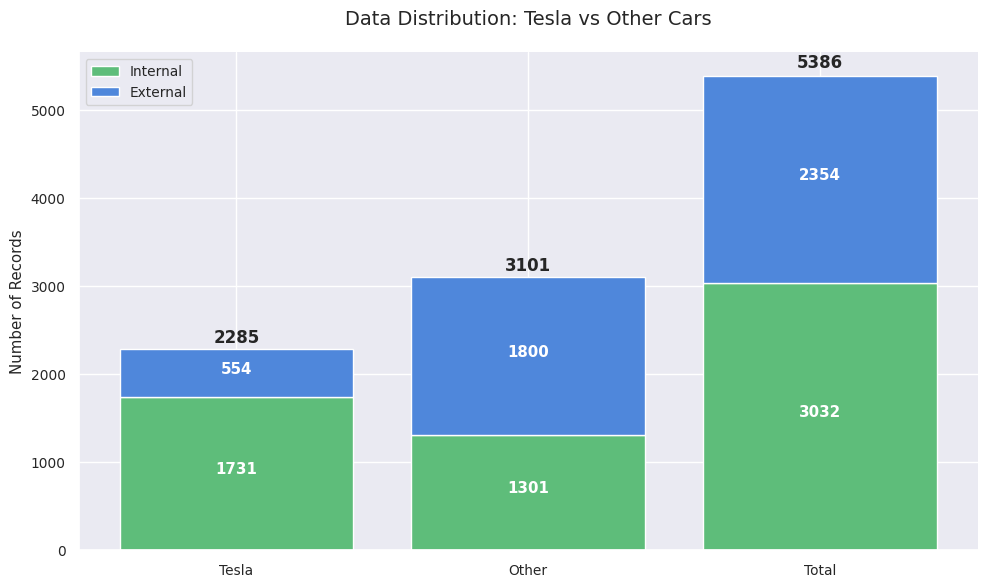

In [18]:
other = 'Other car'
tesla_internal = internal[internal["model"] != other]
tesla_external = external[external["model"] != other]

other_internal = internal[internal["model"] == other]
other_external = external[external["model"] == other]

data = {
    'Category': ['Tesla', 'Other', 'Total'],
    'Internal': [len(tesla_internal), len(other_internal), len(internal)],
    'External': [len(tesla_external), len(other_external), len(external)]
}

df_plot = pd.DataFrame(data)

# 2. Plotting
plt.figure(figsize=(10, 6))

# Plot the Internal bars first
ax = plt.bar(df_plot['Category'], df_plot['Internal'], label='Internal', color="#5EBD7A")

# Plot the External bars on top (bottom parameter creates the stack)
ax2 = plt.bar(df_plot['Category'], df_plot['External'], 
             bottom=df_plot['Internal'], label='External', color="#4F87DB")

# 3. Adding the numbers on top and inside
for i in range(len(df_plot)):
    # Internal Label (middle of bottom bar)
    plt.text(i, df_plot['Internal'][i]/2, str(df_plot['Internal'][i]), 
             ha='center', color='white', fontweight='bold')
    
    # External Label (middle of top bar)
    plt.text(i, df_plot['Internal'][i] + (df_plot['External'][i]/2), 
             str(df_plot['External'][i]), ha='center', color='white', fontweight='bold')
    
    # Total Label (top of the whole stack)
    total = df_plot['Internal'][i] + df_plot['External'][i]
    plt.text(i, total + (total * 0.01), str(total), 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

# 4. Styling
plt.title('Data Distribution: Tesla vs Other Cars', fontsize=14, pad=20)
plt.ylabel('Number of Records')
plt.legend(loc='upper left')
sns.despine() # Clean up borders
plt.tight_layout()

plt.show()